# StrongCNN Seed Sweep: Reproducibility of the Mahalanobis Flip and Seed-to-Seed Adversarial Variation

Thin visualization driver only -- all computation lives in `strong_cnn_seed_sweep.py`, reused
directly here (see `mnist_lipschitz/README.md`'s "notebooks are thin drivers" convention). Five
`StrongCNN` checkpoints are trained (or loaded from cache), identical architecture/recipe, only
the training seed varying, to answer two questions the single-seed `strong_cnn_experiment.py` run
(sibling notebook `notebook_adversarial_strongcnn.ipynb`) could not:

- **Goal A**: does that single run's finding -- that the Euclidean-vs-Mahalanobis gap between
  `max_R_adv` and `L_full_estimated` shrinks dramatically under Mahalanobis distance (the OPPOSITE
  direction from the `SmallCNN` width sweep) -- reproduce across seeds, and is it robust to the
  Mahalanobis shrinkage parameter?
- **Goal B**: with clean test accuracy matched by construction across the five seeds (checked
  directly below, not assumed), how much does adversarial sensitivity vary seed-to-seed? A null
  result (near-identical behavior across seeds) is a valid, reportable answer -- see Goodfellow et
  al. (2015)'s finding that independently-seeded models trained on the same task learn similar
  functions.

**Determinism caveat** (see `strong_cnn_seed_sweep.py`'s top docstring): `torch.manual_seed` is set
per run, but `torch.use_deterministic_algorithms(True)` is NOT forced -- the measured quantity is
*training-run* variation, not *initialization-seed* variation in isolation. Environment recorded
in the cell below.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline

import platform
import torch

from mnist_lipschitz.adversarial import strong_cnn_seed_sweep as sweep
from mnist_lipschitz.adversarial import plots as adv_plots

print("torch", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print(platform.platform())


torch 2.13.0
cuda available: False
macOS-26.5.2-arm64-arm-64bit-Mach-O


## Step 1: train (or load) five seeds, report clean accuracies

Establishes Goal B's premise directly: `run_all_seed_trainings` prints an explicit accuracy-premise
check (max deviation from the across-seed mean, against a 0.5 percentage-point threshold) -- if
this fails, the "matched clean accuracy" framing needs revisiting before anything below is
interpreted.

**Output columns** (`training_summary_df`):
- `seed` -- the training seed (0-4), the only thing that differs between the five runs.
- `train_acc`/`test_acc` -- clean (non-adversarial) accuracy on the full training/test sets.
- `final_train_loss` -- mean cross-entropy loss over the full training set, computed in EVAL mode
  after training finishes (not the noisier per-epoch training-mode running loss printed above --
  see `_eval_mode_mean_loss`'s docstring for why).
- `wall_clock_seconds` -- training time; `0.0` on a cache hit (checkpoint already existed on disk).
- `loaded_from_cache` -- `True` if this seed's checkpoint was loaded rather than retrained.


In [2]:
models_by_seed, test, train, training_summary_df = sweep.run_all_seed_trainings(verbose=True)
training_summary_df


=== seed=0 ===
[checkpoint] loaded seed=0 from /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/adversarial/results/strong_cnn_state_dict_seed0.pt (train_acc=0.9983  test_acc=0.9967  final_train_loss=0.0061)
=== seed=1 ===
[checkpoint] loaded seed=1 from /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/adversarial/results/strong_cnn_state_dict_seed1.pt (train_acc=0.9981  test_acc=0.9966  final_train_loss=0.0064)
=== seed=2 ===
[checkpoint] loaded seed=2 from /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/adversarial/results/strong_cnn_state_dict_seed2.pt (train_acc=0.9980  test_acc=0.9964  final_train_loss=0.0065)
=== seed=3 ===
[checkpoint] loaded seed=3 from /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/adversarial/results/strong_cnn_state_dict_seed3.pt (train_acc=0.9982  test_acc=0.9966  final_train_loss=0.0063)
=== seed=4 ===
[checkpoint] loaded seed=4 from /Users/yichaowang/Documents/P

,seed,train_acc,test_acc,final_train_loss,wall_clock_seconds,loaded_from_cache
0,0,0.998300,0.9967,0.006120,0.0,True
1,1,0.998133,0.9966,0.006356,0.0,True
2,2,0.998050,0.9964,0.006541,0.0,True
3,3,0.998200,0.9966,0.006255,0.0,True
4,4,0.998000,0.9966,0.006524,0.0,True


## Step 2: common evaluation pool

Every seed misclassifies a different subset of clean images; `build_common_pool` intersects the
five seeds' correctly-classified sets so every downstream R_adv comparison uses IDENTICAL images
across seeds -- checked directly (not inferred) inside `build_common_pool` itself.

**Output means:**
- `common pool size` -- how many of the 10,000 test images are classified correctly by ALL FIVE
  seeds (the `pool_idx` this and every later step operates on).
- The fraction printed alongside it is that count divided by the full test-set size (10,000).
- The `verbose=True` printout also shows `per-seed full test_acc` -- each seed's OWN clean
  accuracy on the full 10,000-image test set (should match that seed's `test_acc` in
  `training_summary_df` above, since both measure the same quantity).


In [3]:
pool = sweep.build_common_pool(models_by_seed, test, verbose=True)
print(f"common pool size: {pool['pool_idx'].shape[0]} / {len(test)} "
      f"({pool['pool_idx'].shape[0] / len(test):.4f} of the full test set)")


[common pool] size=9941 / 10000 (0.9941 of the full test set); per-seed full test_acc: {0: 0.9966999888420105, 1: 0.9965999722480774, 2: 0.996399998664856, 3: 0.9965999722480774, 4: 0.9965999722480774}
common pool size: 9941 / 10000 (0.9941 of the full test set)


## Step 3: FGSM attacks + R_adv, both metrics, from the same adversarial examples

`build_r_adv_table` runs FGSM ONCE per (seed, epsilon) and computes BOTH the Euclidean and the
Mahalanobis R_adv from that SAME `x_adv` -- "the same adversarial examples are used for both
metrics" holds by construction, not by post-hoc verification. Also reports the realized/nominal
perturbation-norm ratio (plan section 5.1): `achieved_ratio`'s denominator was confirmed (by
reading its implementation before writing this sweep) to already use the REALIZED `||x-x_adv||`,
not a nominal `epsilon*sqrt(784)` value -- this diagnostic table is the empirical confirmation of
that reading.

**R_adv, the central quantity of this notebook**: `R_adv = ||f(x) - f(x_adv)||_2 / distance(x, x_adv)`
-- how much the model's full logit vector moves, per unit of input-space distance moved by the
attack. The numerator is always plain Euclidean distance in LOGIT space; only the denominator
(`distance`) changes between the `_euclidean`/`_mahalanobis` columns below.

**Output columns** (`realized_norm_diagnostic_df`):
- `seed`, `epsilon` -- which checkpoint and which attack budget.
- `mean_realized_over_nominal` -- mean ACTUAL perturbation size (`||x - x_adv||_2`, after FGSM's
  `[0, 1]` pixel clipping) divided by the NOMINAL maximum possible size (`epsilon * sqrt(784)`,
  what the perturbation would be with no clipping). A value below 1 means clipping is happening
  (expected: many MNIST pixels are already saturated at 0, so FGSM can't move them the full
  `epsilon`).

**Console output during `build_r_adv_table` (`verbose=True`)**, per `(seed, epsilon)`:
- `pct_misclassified` -- fraction of the common pool whose prediction flips under this attack.
- `mean_realized_norm` -- mean `||x - x_adv||_2` (same quantity averaged in
  `mean_realized_over_nominal` above, but in absolute units here).
- `nominal` -- `epsilon * sqrt(784)`, see above.
- `ratio` -- `mean_realized_norm / nominal` (same as `mean_realized_over_nominal`).

**The table this cell actually builds** (`r_adv_df`, used throughout the rest of the notebook, not
displayed directly here) has one row per `(seed, epsilon, pool position)`:
- `pool_position`/`test_index` -- position within the pool / the image's index in the original
  10,000-image test set.
- `realized_norm` -- this example's own `||x - x_adv||_2`.
- `is_misclassified` -- whether the attack flipped this example's prediction.
- `clean_margin` -- the CLEAN (unattacked) top-1-minus-runner-up logit margin for this image, under
  this seed's model -- a rough proxy for "how close to the decision boundary" the clean image
  already was.
- `R_adv_euclidean`/`R_adv_mahalanobis` -- this example's R_adv under each distance metric,
  computed from the SAME `x_adv` (only the denominator differs).


In [4]:
mahalanobis_distance_fn = sweep.fit_shared_mahalanobis_distance_fn(train, epsilon=sweep.MAHALANOBIS_EPSILON)
r_adv_df, realized_norm_diagnostic_df = sweep.build_r_adv_table(
    models_by_seed, test, pool, mahalanobis_distance_fn, epsilons=sweep.EPSILONS, verbose=True)
realized_norm_diagnostic_df


  seed=0  epsilon=0.1  pct_misclassified=0.6568  mean_realized_norm=2.1545  (nominal=2.8000, ratio=0.7695)


  seed=0  epsilon=0.2  pct_misclassified=0.8987  mean_realized_norm=4.2715  (nominal=5.6000, ratio=0.7628)


  seed=1  epsilon=0.1  pct_misclassified=0.5665  mean_realized_norm=2.1493  (nominal=2.8000, ratio=0.7676)


  seed=1  epsilon=0.2  pct_misclassified=0.8525  mean_realized_norm=4.2618  (nominal=5.6000, ratio=0.7610)


  seed=2  epsilon=0.1  pct_misclassified=0.6639  mean_realized_norm=2.1695  (nominal=2.8000, ratio=0.7748)


...

  seed=3  epsilon=0.1  pct_misclassified=0.5735  mean_realized_norm=2.1424  (nominal=2.8000, ratio=0.7651)


  seed=3  epsilon=0.2  pct_misclassified=0.8913  mean_realized_norm=4.2477  (nominal=5.6000, ratio=0.7585)


  seed=4  epsilon=0.1  pct_misclassified=0.5385  mean_realized_norm=2.1897  (nominal=2.8000, ratio=0.7820)


  seed=4  epsilon=0.2  pct_misclassified=0.8812  mean_realized_norm=4.3444  (nominal=5.6000, ratio=0.7758)


,seed,epsilon,mean_realized_over_nominal
0,0,0.1,0.769461
1,0,0.2,0.762770
2,1,0.1,0.767611
3,1,0.2,0.761036
4,2,0.1,0.774811
5,2,0.2,0.768198
6,3,0.1,0.765138
7,3,0.2,0.758520
8,4,0.1,0.782038
9,4,0.2,0.775782


## Step 4: Mahalanobis shrinkage sensitivity (Goal A)

Refits the Mahalanobis precision matrix at `epsilon in {0.01, 0.1}` and recomputes R_adv's
denominator only -- no retraining, no re-attacking (FGSM has no randomness at all, so `x_adv` is
fully determined by `(model, x, y, attack_epsilon)`, independent of the Mahalanobis shrinkage
parameter).

**Output**: `.describe()` on `R_adv_mahalanobis`, grouped by `(seed, attack_epsilon, maha_epsilon)`
-- standard pandas summary statistics per group: `count` (pool size), `mean`, `std`, `min`,
`25%`/`50%`/`75%` (quartiles, `50%` = median), `max`.

**Console output during `run_shrinkage_sensitivity`**: one `[shrinkage sweep] fitting Mahalanobis
precision at epsilon=...` line per `maha_epsilon` value tested -- confirms a fresh precision
matrix is being fit (not the default `MAHALANOBIS_EPSILON=0.01` one used in Step 3 above).


In [5]:
shrinkage_df = sweep.run_shrinkage_sensitivity(
    models_by_seed, test, train, pool, r_adv_df,
    epsilons_maha=sweep.MAHALANOBIS_EPSILONS_SWEEP, attack_epsilons=sweep.EPSILONS, verbose=True)
shrinkage_df.groupby(["seed", "attack_epsilon", "maha_epsilon"])["R_adv_mahalanobis"].describe()


[shrinkage sweep] fitting Mahalanobis precision at epsilon=0.01...


[shrinkage sweep] fitting Mahalanobis precision at epsilon=0.1...


count      mean       std       min  \
seed attack_epsilon maha_epsilon                                         
0    0.1            0.01          9941.0  1.224860  0.233285  0.352060   
                    0.10          9941.0  3.209472  0.589825  0.931689   
     0.2            0.01          9941.0  0.727418  0.130802  0.200215   
                    0.10          9941.0  1.912263  0.332307  0.531031   
1    0.1            0.01          9941.0  1.173427  0.229945  0.331529   
                    0.10          9941.0  3.074159  0.575306  0.897102   
     0.2            0.01          9941.0  0.723081  0.132175  0.185710   
                    0.10          9941.0  1.900761  0.331733  0.503444   
2    0.1            0.01          9941.0  1.265205  0.235007  0.417804   
                    0.10          9941.0  3.319820  0.589252  1.097804   
     0.2            0.01          9941.0  0.744995  0.137099  0.263143   
                    0.10          9941.0  1.960965  0.345475  0.720891   
3    0.1            0.01          9941.0  1.182779  0.225987  0.272596   
                    0.10          9941.0  3.106861  0.575218  0.720323   
     0.2            0.01          9941.0  0.715509  0.131076  0.167448   
                    0.10          9941.0  1.885541  0.335245  0.443103   
4    0.1            0.01          9941.0  1.218834  0.247816  0.521588   
                    0.10          9941.0  3.162012  0.577873  1.368323   
     0.2            0.01          9941.0  0.745675  0.142228  0.311496   
                    0.10          9941.0  1.941747  0.338988  0.834275   

                                       25%       50%       75%       max  
seed attack_epsilon maha_epsilon                                          
0    0.1            0.01          1.062037  1.226390  1.381827  2.090071  
                    0.10          2.808866  3.215767  3.582678  5.238084  
     0.2            0.01          0.637845  0.731191  0.818719  1.144415  
                    0.10          1.692887  1.923307  2.133041  2.951704  
1    0.1            0.01          1.003356  1.156803  1.349973  1.923716  
                    0.10          2.659471  3.044253  3.504081  4.911969  
     0.2            0.01          0.631141  0.726881  0.823228  1.141001  
                    0.10          1.675096  1.915596  2.143283  2.921835  
2    0.1            0.01          1.097987  1.261935  1.438304  2.061756  
                    0.10          2.910266  3.311032  3.737724  5.250957  
     0.2            0.01          0.649764  0.747385  0.843209  1.179712  
                    0.10          1.727505  1.965395  2.204667  3.021440  
3    0.1            0.01          1.021920  1.183832  1.325322  2.092137  
                    0.10          2.700801  3.112584  3.476664  5.332714  
     0.2            0.01          0.627200  0.716762  0.800658  1.177057  
                    0.10          1.663451  1.888179  2.105893  2.983402  
4    0.1            0.01          1.047437  1.183730  1.353821  2.094465  
                    0.10          2.766957  3.105864  3.503490  5.136366  
     0.2            0.01          0.645801  0.734526  0.839771  1.211661  
                    0.10          1.710312  1.927505  2.167627  3.112722

`run_shrinkage_sensitivity` only varies R_adv's denominator -- answering "does the flip survive a
different epsilon" for Goal A also needs `L_full_estimated` recomputed at each shrinkage value
(`shrinkage_bounds_per_seed`), since Goal A is specifically about the GAP between R_adv and that
bound, not R_adv in isolation.

**Console output during `shrinkage_bounds_per_seed`** (via `per_seed_bounds` internally), per
`(seed, maha_epsilon)`: `L_head_exact` (exact spectral-norm Lipschitz constant of the final linear
layer), `L_extractor_est` (estimated Lipschitz constant of everything before it), `L_full_est`
(estimated Lipschitz constant of the whole network -- the TIGHT bound R_adv is compared against),
`looseness_ratio` (`L_extractor_est * L_head_exact / L_full_est` -- how much looser the
submultiplicative bound is than the tight one; `1.0` would mean the bound is exactly tight).

**Output columns** (`shrinkage_ratio_df`, the table actually displayed):
- `seed`, `maha_epsilon`, `attack_epsilon` -- which checkpoint, which Mahalanobis shrinkage value,
  which attack budget.
- `p99_R_adv` -- the 99th percentile of `R_adv_mahalanobis` at this shrinkage value (from
  `shrinkage_df` above).
- `L_full_estimated` -- the tight Lipschitz bound, RECOMPUTED at this same shrinkage value (the
  point of this cell: `run_shrinkage_sensitivity` alone only varies R_adv's denominator, not this
  bound, so the ratio below would be wrong without this recomputation).
- `ratio_to_L_full` -- `p99_R_adv / L_full_estimated`. Values above 1 mean the achieved
  sensitivity EXCEEDS the tight theoretical bound at the 99th percentile; below 1 means it stays
  comfortably under it.


In [6]:
shrinkage_bounds_df = sweep.shrinkage_bounds_per_seed(
    models_by_seed, train, test, pool, epsilons_maha=sweep.MAHALANOBIS_EPSILONS_SWEEP, verbose=True)

import pandas as pd
rows = []
for maha_epsilon in sweep.MAHALANOBIS_EPSILONS_SWEEP:
    metric_label = f"Mahalanobis_eps{maha_epsilon:g}"
    for seed in sweep.SEEDS:
        L_full = shrinkage_bounds_df[(shrinkage_bounds_df["seed"] == seed)
                                      & (shrinkage_bounds_df["metric"] == metric_label)]["L_full_estimated"].iloc[0]
        for attack_epsilon in sweep.EPSILONS:
            case = shrinkage_df[(shrinkage_df["seed"] == seed) & (shrinkage_df["maha_epsilon"] == maha_epsilon)
                                 & (shrinkage_df["attack_epsilon"] == attack_epsilon)]
            p99 = case["R_adv_mahalanobis"].quantile(0.99)
            rows.append({"seed": seed, "maha_epsilon": maha_epsilon, "attack_epsilon": attack_epsilon,
                         "p99_R_adv": p99, "L_full_estimated": L_full, "ratio_to_L_full": p99 / L_full})
shrinkage_ratio_df = pd.DataFrame(rows)
shrinkage_ratio_df.sort_values(["attack_epsilon", "maha_epsilon", "seed"])


[bounds] seed=0  metric=Mahalanobis_eps0.01


  [distance_fn='<lambda>'] L_head_exact=2.0859  L_extractor_est=1.1290  L_full_est=1.6457  looseness_ratio=1.4309
[bounds] seed=1  metric=Mahalanobis_eps0.01


  [distance_fn='<lambda>'] L_head_exact=2.1522  L_extractor_est=1.1297  L_full_est=1.6769  looseness_ratio=1.4499
[bounds] seed=2  metric=Mahalanobis_eps0.01


  [distance_fn='<lambda>'] L_head_exact=2.1994  L_extractor_est=1.1984  L_full_est=1.8355  looseness_ratio=1.4360
[bounds] seed=3  metric=Mahalanobis_eps0.01


  [distance_fn='<lambda>'] L_head_exact=2.1220  L_extractor_est=1.1140  L_full_est=1.6688  looseness_ratio=1.4166
[bounds] seed=4  metric=Mahalanobis_eps0.01


...

  [distance_fn='<lambda>'] L_head_exact=2.1522  L_extractor_est=1.7717  L_full_est=2.6838  looseness_ratio=1.4207
[bounds] seed=2  metric=Mahalanobis_eps0.1


  [distance_fn='<lambda>'] L_head_exact=2.1994  L_extractor_est=1.9240  L_full_est=2.9449  looseness_ratio=1.4370
[bounds] seed=3  metric=Mahalanobis_eps0.1


  [distance_fn='<lambda>'] L_head_exact=2.1220  L_extractor_est=1.7509  L_full_est=2.7899  looseness_ratio=1.3318
[bounds] seed=4  metric=Mahalanobis_eps0.1


  [distance_fn='<lambda>'] L_head_exact=2.1308  L_extractor_est=1.7696  L_full_est=2.6849  looseness_ratio=1.4044


,seed,maha_epsilon,attack_epsilon,p99_R_adv,L_full_estimated,ratio_to_L_full
0,0,0.01,0.1,1.787525,1.645742,1.086151
2,1,0.01,0.1,1.667529,1.676907,0.994408
4,2,0.01,0.1,1.784871,1.835455,0.972441
6,3,0.01,0.1,1.752571,1.668830,1.050180
8,4,0.01,0.1,1.839682,1.668867,1.102354
10,0,0.10,0.1,4.639136,2.638203,1.758446
12,1,0.10,0.1,4.338610,2.683831,1.616573
14,2,0.10,0.1,4.646832,2.944860,1.577947
16,3,0.10,0.1,4.497863,2.789865,1.612215
18,4,0.10,0.1,4.586391,2.684886,1.708225


## Step 5: statistics

Primary cross-seed statistic (plan section 7.1): UNCONDITIONAL R_adv on the full common pool,
per seed x epsilon x metric -- p99 is the headline (max is a single-sample statistic dominated by
whichever image happened to land in the tail for that seed).

**Output columns** (`primary_stats_df`):
- `seed`, `epsilon`, `metric` -- which checkpoint, attack budget, and distance metric.
- `median`/`p95`/`p99`/`max` -- percentiles of the UNCONDITIONAL R_adv distribution (every example
  in the common pool, regardless of attack outcome). `p99` is this sweep's headline statistic
  (see the markdown above) -- `max` is shown for reference but is noisier (a single-sample
  statistic).


In [7]:
primary_stats_euclidean = sweep.primary_r_adv_stats(r_adv_df, "R_adv_euclidean", "Euclidean")
primary_stats_mahalanobis = sweep.primary_r_adv_stats(r_adv_df, "R_adv_mahalanobis", "Mahalanobis")
import pandas as pd
primary_stats_df = pd.concat([primary_stats_euclidean, primary_stats_mahalanobis], ignore_index=True)
primary_stats_df.sort_values(["epsilon", "metric", "seed"])


,seed,epsilon,median,p95,p99,max,metric
0,0,0.1,8.379214,11.101141,12.063196,13.483820,Euclidean
2,1,0.1,7.961264,10.473060,11.470695,13.003027,Euclidean
4,2,0.1,8.662912,11.089747,12.040233,13.638951,Euclidean
6,3,0.1,8.150428,10.670234,11.606491,13.124807,Euclidean
8,4,0.1,8.085742,10.189051,11.425391,12.810763,Euclidean
10,0,0.1,1.226390,1.615828,1.787525,2.090071,Mahalanobis
12,1,0.1,1.156803,1.542606,1.667529,1.923716,Mahalanobis
14,2,0.1,1.261935,1.648028,1.784871,2.061756,Mahalanobis
16,3,0.1,1.183832,1.572625,1.752571,2.092137,Mahalanobis
18,4,0.1,1.183730,1.705216,1.839682,2.094465,Mahalanobis


**Output columns** (`success_rate_df`):
- `seed`, `epsilon` -- which checkpoint and attack budget.
- `attack_success_rate` -- fraction of the common pool whose prediction was flipped by the attack
  (the mean of `is_misclassified`). This is METRIC-INDEPENDENT -- it depends only on the model's
  prediction on `x_adv`, not on how distance is measured, so it's reported once, not once per
  metric (see `attack_success_rate`'s docstring).


In [8]:
success_rate_df = sweep.attack_success_rate(r_adv_df)
success_rate_df


,seed,epsilon,attack_success_rate
0,0,0.1,0.656775
1,0,0.2,0.898702
2,1,0.1,0.566543
3,1,0.2,0.852530
4,2,0.1,0.663917
5,2,0.2,0.888241
6,3,0.1,0.573484
7,3,0.2,0.891258
8,4,0.1,0.538477
9,4,0.2,0.881199


**Within-seed diagnostic only** (plan section 7.3) -- NOT a cross-seed comparison statistic (the
attack succeeds on a different image subset per seed, and success correlates with small clean
margin). Reported alongside the mean clean margin per bucket so that confound is visible, not
hidden.

**Output columns** (`by_outcome_euclidean`):
- `seed`, `epsilon`, `is_misclassified` -- which checkpoint/budget, and which outcome bucket
  (`True` = attack succeeded, `False` = prediction stayed correct).
- `median`/`p95` -- R_adv percentiles WITHIN that outcome bucket only.
- `n` -- how many pool images fall in that bucket.
- `mean_clean_margin` -- mean clean (pre-attack) margin within that bucket -- the confound this
  split is designed to surface: misclassified images tend to have a smaller clean margin (i.e.
  were already closer to the decision boundary) than correctly-classified ones.


In [9]:
by_outcome_euclidean = sweep.by_outcome_split(r_adv_df, "R_adv_euclidean", "Euclidean")
by_outcome_euclidean


,seed,epsilon,is_misclassified,median,p95,n,mean_clean_margin,metric
0,0,0.1,False,8.052125,10.512044,3412,14.474329,Euclidean
1,0,0.1,True,8.525954,11.330442,6529,11.653474,Euclidean
2,0,0.2,False,4.614951,5.889495,1007,15.656652,Euclidean
3,0,0.2,True,5.029455,6.472442,8934,12.279572,Euclidean
4,1,0.1,False,7.560905,9.782336,4309,14.386045,Euclidean
5,1,0.1,True,8.359584,10.779338,5632,11.608360,Euclidean
6,1,0.2,False,4.587735,5.612338,1466,15.158917,Euclidean
7,1,0.2,True,5.048641,6.375784,8475,12.406464,Euclidean
8,2,0.1,False,8.387092,10.836817,3341,14.557526,Euclidean
9,2,0.1,True,8.837292,11.199647,6600,11.457275,Euclidean


**Output means**, printed per `epsilon`:
- `n` -- size of the "common success set": images misclassified by ALL FIVE seeds at this epsilon
  (metric-independent, same reasoning as `attack_success_rate` above).
- `reliable` -- `True` if `n` is at least 50 (the plan's minimum-reliable-size threshold); below
  that, the set is too small for its own statistics to be trustworthy and should be treated as
  illustrative only.


In [10]:
common_success_sets = {epsilon: sweep.common_success_set(r_adv_df, epsilon) for epsilon in sweep.EPSILONS}
for epsilon, result in common_success_sets.items():
    print(f"epsilon={epsilon:g}: common success set n={result['n']} "
          f"(reliable={result['reliable']})")


epsilon=0.1: common success set n=4018 (reliable=True)
epsilon=0.2: common success set n=7722 (reliable=True)


**L_full_estimated per seed, elevated to headline** (plan section 7.5): attack-independent, so
free of every pool/outcome confound above, but seed-dependent. Computed under BOTH metrics, since
Goal A is specifically about the gap between `max_R_adv`/p99 and `L_full_estimated`.

**Output columns** (`bounds_df`):
- `seed`, `metric` -- which checkpoint and distance metric (`Euclidean`/`Mahalanobis`).
- `L_head_exact` -- exact (not estimated) spectral-norm Lipschitz constant of the final linear
  layer; identical between metrics by construction (see `strong_cnn_experiment.py`'s README
  section for why).
- `L_extractor_estimated` -- empirically estimated Lipschitz constant of everything before the
  final layer.
- `L_full_estimated` -- empirically estimated Lipschitz constant of the WHOLE network -- the TIGHT
  bound R_adv is compared against elsewhere in this notebook.
- `product` -- `L_extractor_estimated * L_head_exact`, the LOOSE submultiplicative bound (Szegedy
  et al. 2014).
- `looseness_ratio` -- `product / L_full_estimated`; how many times looser the easy-to-compute
  per-layer bound is than the network's actual (estimated) end-to-end sensitivity.


In [11]:
bounds_df = sweep.per_seed_bounds(
    models_by_seed, train, test, pool,
    {"Euclidean": sweep.euclidean_distance_fn, "Mahalanobis": mahalanobis_distance_fn},
    verbose=True)
bounds_df


[bounds] seed=0  metric=Euclidean


  [distance_fn='euclidean_distance_fn'] L_head_exact=2.0859  L_extractor_est=3.0477  L_full_est=4.4215  looseness_ratio=1.4378
[bounds] seed=0  metric=Mahalanobis


  [distance_fn='<lambda>'] L_head_exact=2.0859  L_extractor_est=1.1290  L_full_est=1.6457  looseness_ratio=1.4309
[bounds] seed=1  metric=Euclidean


  [distance_fn='euclidean_distance_fn'] L_head_exact=2.1522  L_extractor_est=3.0817  L_full_est=4.4926  looseness_ratio=1.4763
[bounds] seed=1  metric=Mahalanobis


  [distance_fn='<lambda>'] L_head_exact=2.1522  L_extractor_est=1.1297  L_full_est=1.6769  looseness_ratio=1.4499
[bounds] seed=2  metric=Euclidean


...

  [distance_fn='euclidean_distance_fn'] L_head_exact=2.1220  L_extractor_est=3.0166  L_full_est=4.3871  looseness_ratio=1.4591
[bounds] seed=3  metric=Mahalanobis


  [distance_fn='<lambda>'] L_head_exact=2.1220  L_extractor_est=1.1140  L_full_est=1.6688  looseness_ratio=1.4166
[bounds] seed=4  metric=Euclidean


  [distance_fn='euclidean_distance_fn'] L_head_exact=2.1308  L_extractor_est=3.1213  L_full_est=4.4657  looseness_ratio=1.4893
[bounds] seed=4  metric=Mahalanobis


  [distance_fn='<lambda>'] L_head_exact=2.1308  L_extractor_est=1.1532  L_full_est=1.6689  looseness_ratio=1.4724


,seed,metric,L_head_exact,L_extractor_estimated,L_full_estimated,product,looseness_ratio
0,0,Euclidean,2.085902,3.047687,4.421465,6.357177,1.437799
1,0,Mahalanobis,2.085902,1.128979,1.645742,2.354940,1.430929
2,1,Euclidean,2.152200,3.081702,4.492618,6.632438,1.476297
3,1,Mahalanobis,2.152200,1.129692,1.676907,2.431322,1.449885
4,2,Euclidean,2.199414,3.059688,4.508818,6.729521,1.492525
5,2,Mahalanobis,2.199414,1.198385,1.835455,2.635744,1.436017
6,3,Euclidean,2.122039,3.016603,4.387073,6.401349,1.459139
7,3,Mahalanobis,2.122039,1.114023,1.668830,2.364000,1.416562
8,4,Euclidean,2.130836,3.121288,4.465693,6.650954,1.489344
9,4,Mahalanobis,2.130836,1.153153,1.668867,2.457180,1.472365


**Output columns** (`project1_summary_df`, one row per seed -- the headline table combining
everything above):
- `seed`, `train_acc`, `test_acc` -- from Step 1.
- `adv_acc_eps0.1`/`adv_acc_eps0.2` -- adversarial accuracy (`1 - attack_success_rate`) at each
  epsilon -- metric-independent, same quantity as `success_rate_df` above, inverted.
- `L_full_estimated_euclidean`/`_mahalanobis` -- the tight Lipschitz bound under each metric (from
  `bounds_df`).
- `product_bound_euclidean`/`_mahalanobis` -- the loose submultiplicative bound under each metric.
- `looseness_ratio_euclidean`/`_mahalanobis` -- how loose the easy bound is relative to the tight
  one, under each metric.
- `p99_R_adv_euclidean_eps0.2`/`_mahalanobis_eps0.2` -- this sweep's headline statistic (99th
  percentile of achieved sensitivity) at the LARGEST swept epsilon, under each metric -- the
  number to compare directly against the corresponding `L_full_estimated` column to answer Goal A.


In [12]:
project1_summary_df = sweep.build_project1_summary_table(training_summary_df, r_adv_df, bounds_df,
                                                          epsilons=sweep.EPSILONS)
project1_summary_df


,seed,train_acc,test_acc,adv_acc_eps0.1,adv_acc_eps0.2,L_full_estimated_euclidean,product_bound_euclidean,looseness_ratio_euclidean,p99_R_adv_euclidean_eps0.2,L_full_estimated_mahalanobis,product_bound_mahalanobis,looseness_ratio_mahalanobis,p99_R_adv_mahalanobis_eps0.2
0,0,0.998300,0.9967,0.343225,0.101298,4.421465,6.357177,1.437799,6.932671,1.645742,2.354940,1.430929,1.019584
1,1,0.998133,0.9966,0.433457,0.147470,4.492618,6.632438,1.476297,6.895773,1.676907,2.431322,1.449885,0.995522
2,2,0.998050,0.9964,0.336083,0.111759,4.508818,6.729521,1.492525,7.130943,1.835455,2.635744,1.436017,1.044979
3,3,0.998200,0.9966,0.426516,0.108742,4.387073,6.401349,1.459139,6.895969,1.668830,2.364000,1.416562,1.029811
4,4,0.998000,0.9966,0.461523,0.118801,4.465693,6.650954,1.489344,6.953807,1.668867,2.457180,1.472365,1.080980


## Step 6: plots

**`plot_strong_cnn_seed_sweep_r_adv_outcome_grid`** -- a grid of histograms, one panel per
`(seed, epsilon x metric)` combination: the DISTRIBUTION of R_adv across the common pool, colored
by attack outcome (green = still correctly classified, red = misclassified). This is the
distribution `by_outcome_euclidean`/`by_outcome_mahalanobis` (Step 5) summarize numerically.


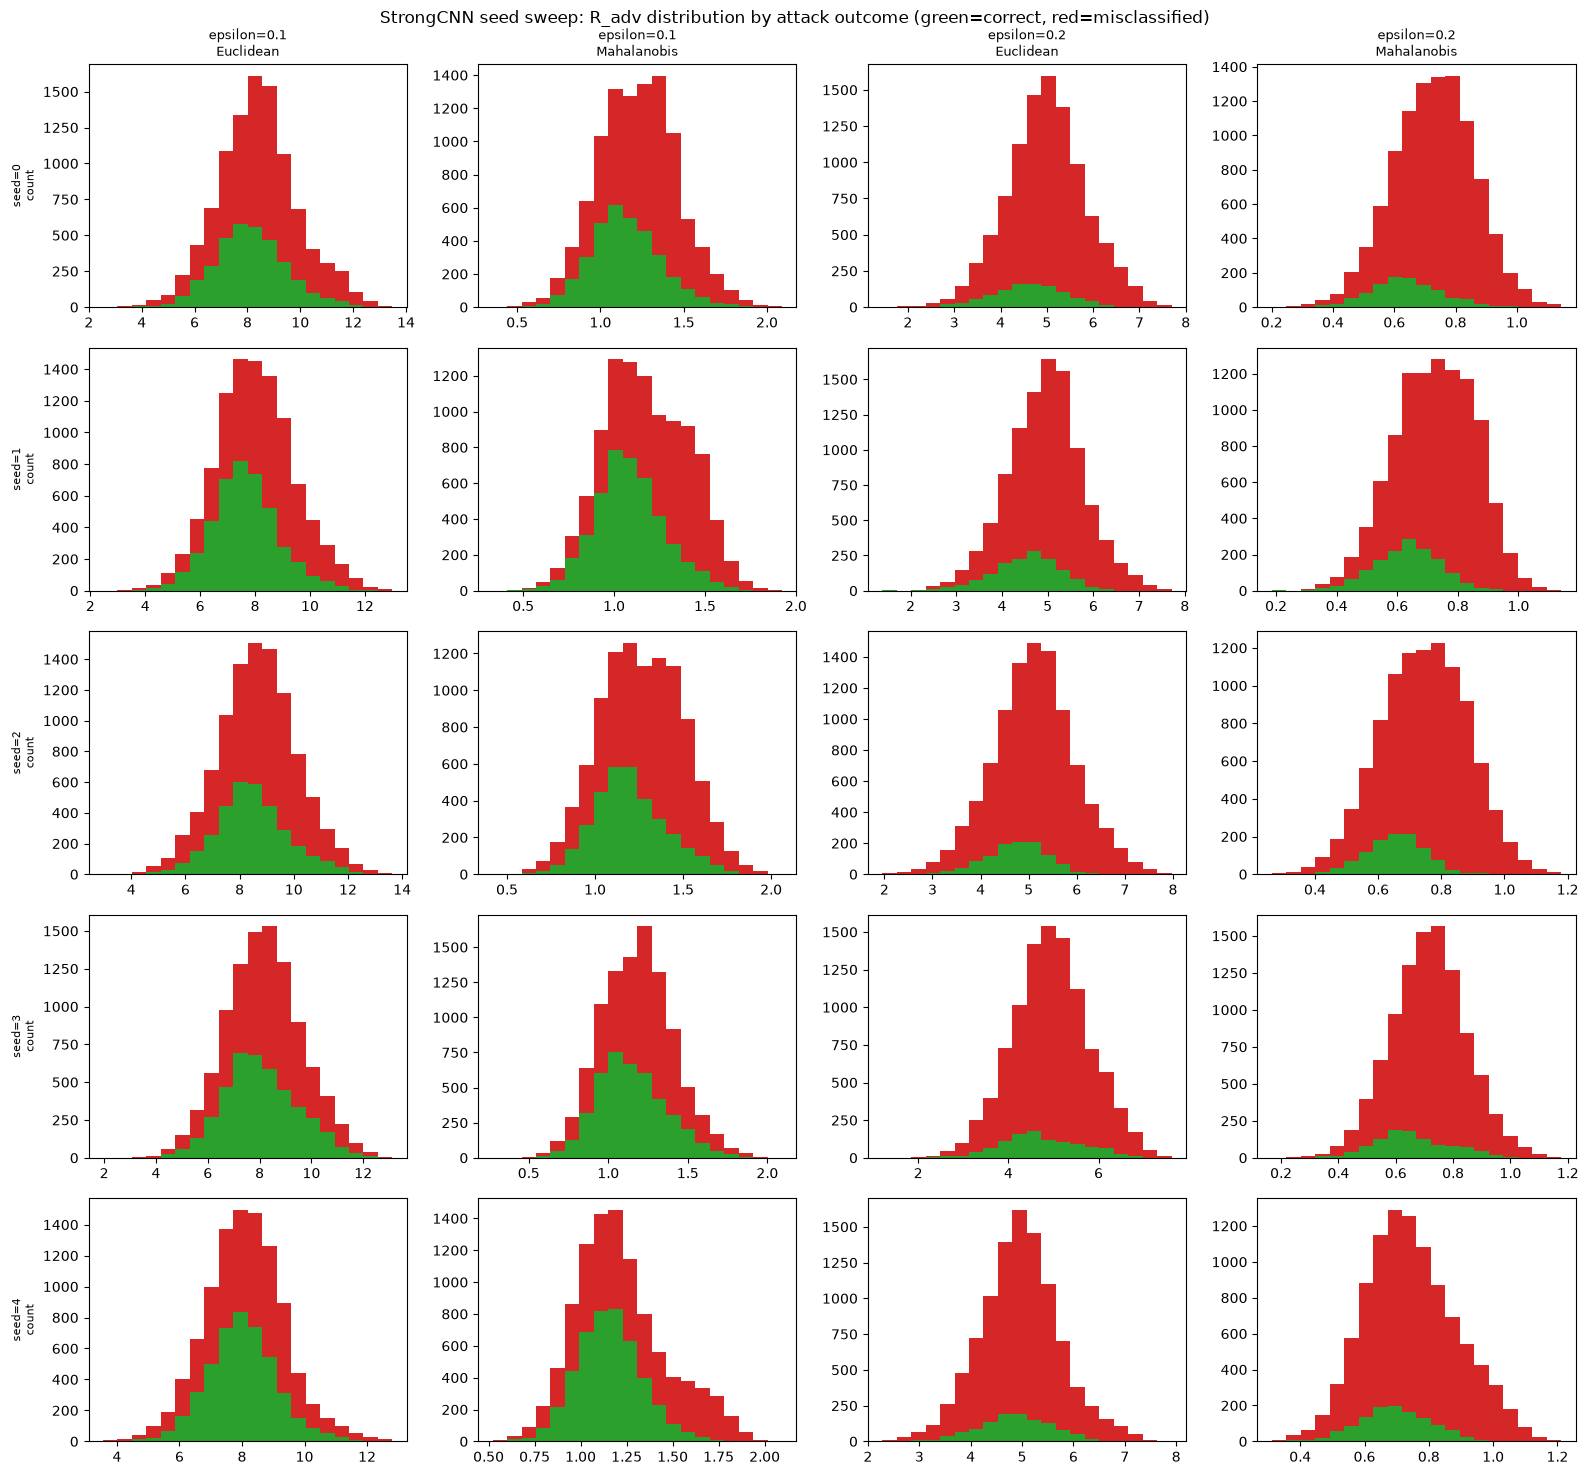

In [13]:
fig_grid = adv_plots.plot_strong_cnn_seed_sweep_r_adv_outcome_grid(
    r_adv_df, save_path=sweep.RESULTS_DIR / "strong_cnn_seed_sweep_r_adv_outcome_grid.png")


**Primary figure for Goal B** -- unconditional R_adv across seeds, on the identical common pool.

Each panel overlays all five seeds' R_adv distributions (one epsilon x metric combination per
panel) as density histograms -- if the five curves overlap closely, seed-to-seed variation in the
overall sensitivity distribution is small; visible separation would indicate real model-to-model
differences (see Step 5's `primary_stats_df` for the numeric version of the same comparison).


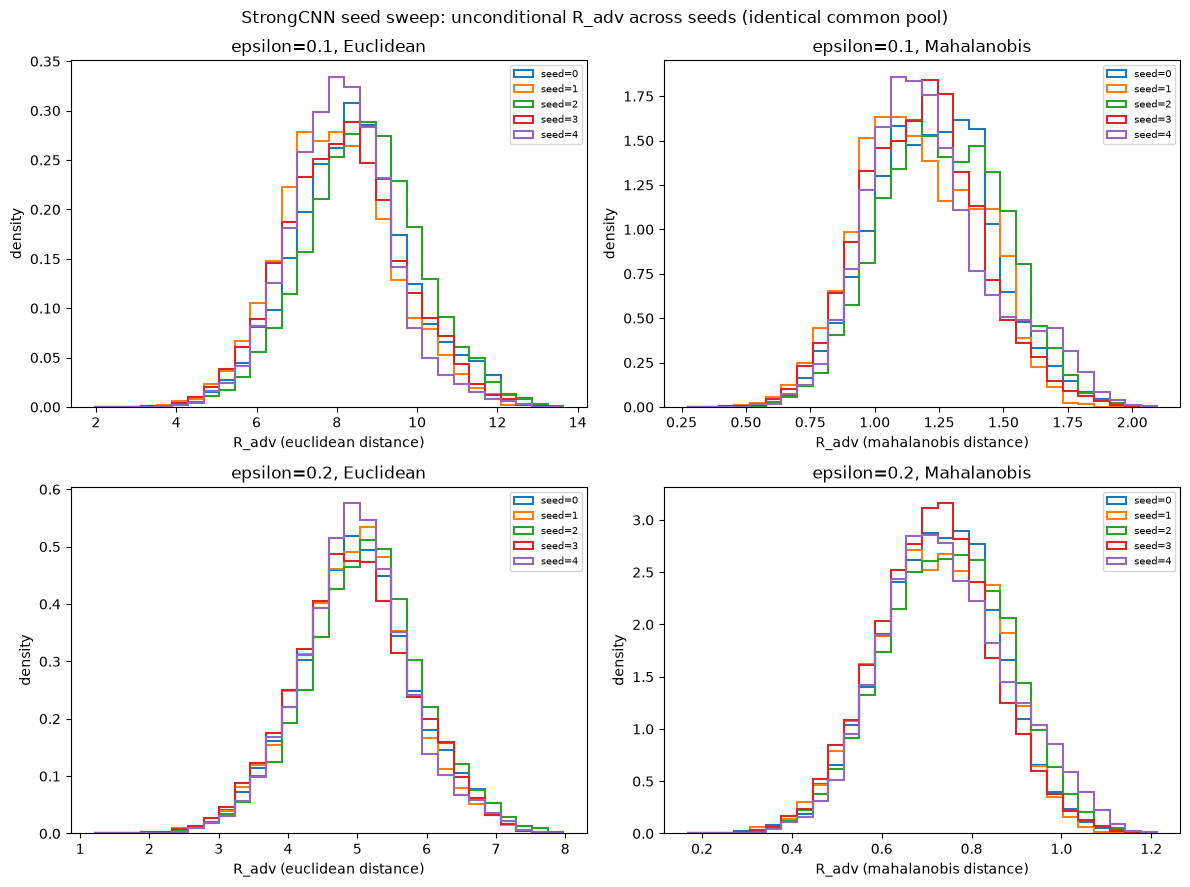

In [14]:
fig_cross_seed = adv_plots.plot_strong_cnn_seed_sweep_cross_seed_overlay(
    r_adv_df, save_path=sweep.RESULTS_DIR / "strong_cnn_seed_sweep_cross_seed_overlay.png")


**Primary figure for Goal A** -- p99(R_adv) vs. L_full_estimated, Euclidean vs. Mahalanobis, per seed.

Bars show `p99_R_adv` (from `primary_stats_df`) per seed, Euclidean vs. Mahalanobis side by side;
the black tick marks show each seed's OWN `L_full_estimated` (from `bounds_df`) under the matching
metric. A bar taller than its tick mark means the 99th-percentile achieved sensitivity EXCEEDS the
tight theoretical bound; a bar shorter than its tick mark means it stays comfortably under it.


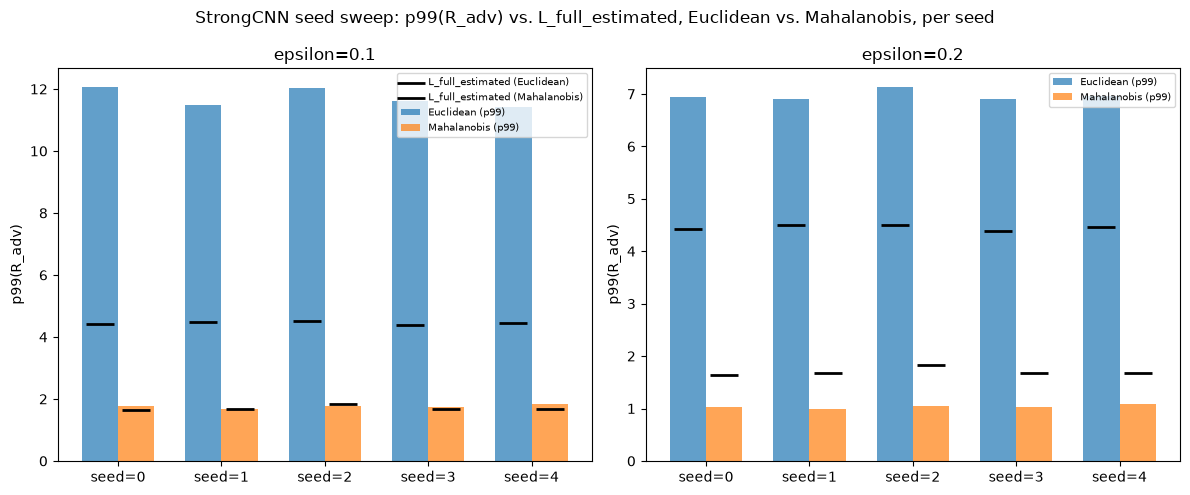

In [15]:
fig_eucl_vs_maha = adv_plots.plot_strong_cnn_seed_sweep_euclidean_vs_mahalanobis(
    primary_stats_df, bounds_df, stat="p99",
    save_path=sweep.RESULTS_DIR / "strong_cnn_seed_sweep_euclidean_vs_mahalanobis.png")


Renders `project1_summary_df` (Step 5's headline table) as an image for easy inclusion in a
write-up -- same columns/meanings as explained above, just a visual rendering, not a new
computation.


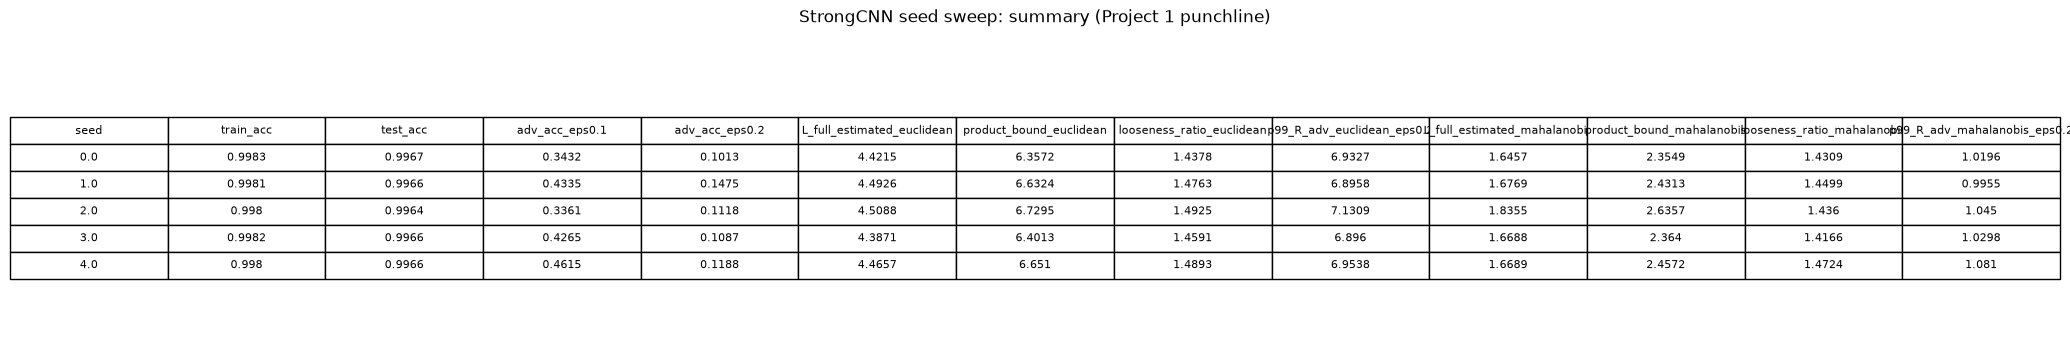

In [16]:
fig_summary_table = adv_plots.plot_strong_cnn_seed_sweep_summary_table(
    project1_summary_df, save_path=sweep.RESULTS_DIR / "strong_cnn_seed_sweep_summary_table.png")


Least/most sensitive attacked example, per seed x epsilon (`extract_extreme_example` re-runs FGSM
for just the one flagged (seed, epsilon) case to recover the actual image pair -- `r_adv_df` itself
only stores scalars).

Each panel shows: the clean image (with its true label and clean prediction), the adversarial
image (with its post-attack prediction), and the pixel-difference image; the row label gives
`R_adv` (this example's achieved sensitivity ratio) and the `epsilon`/`method` that produced it.


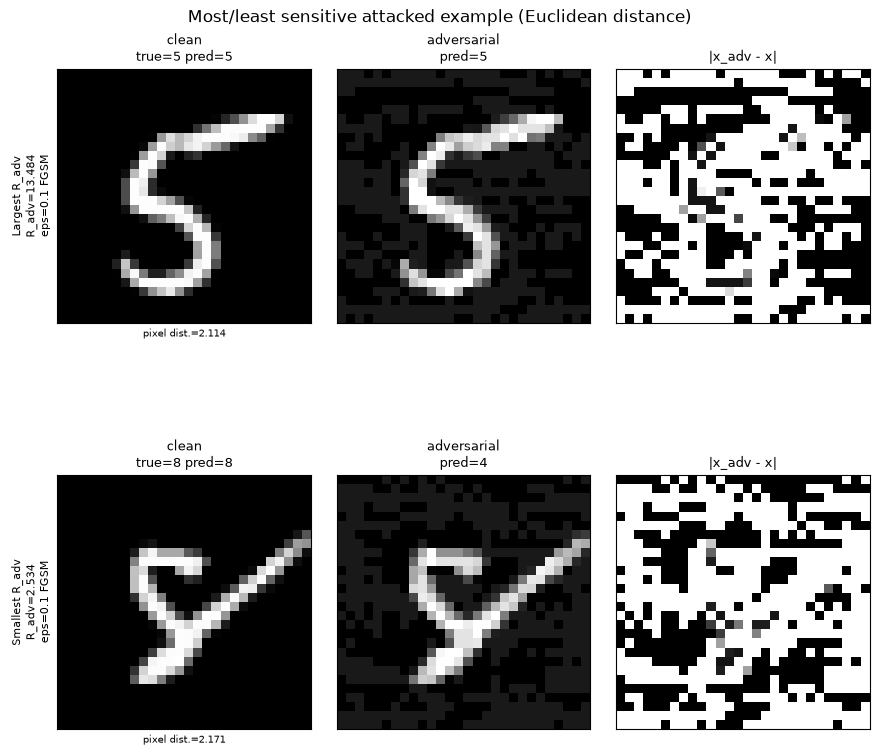

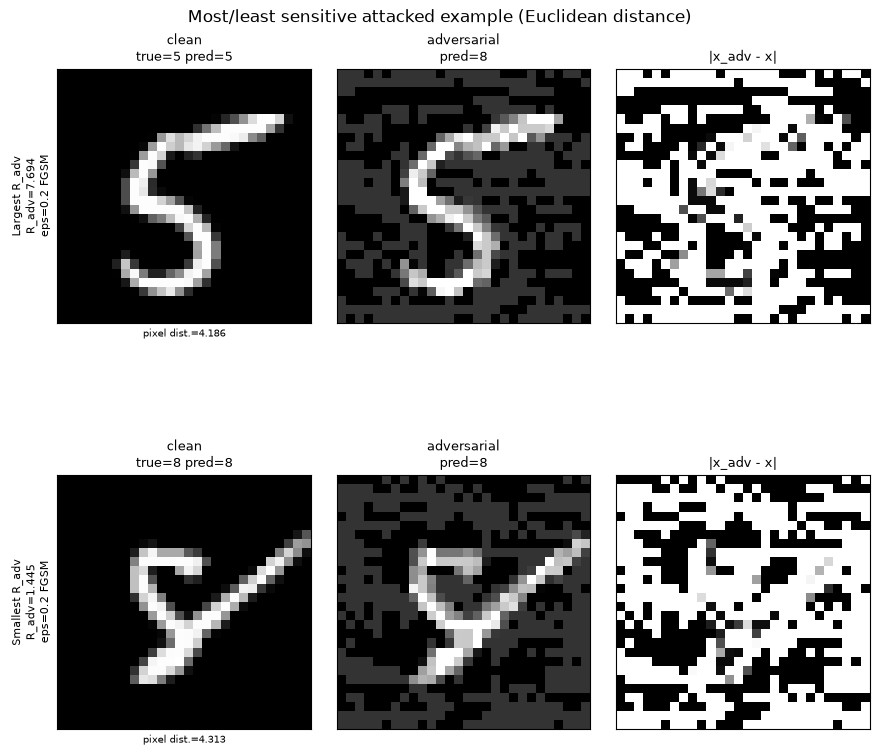

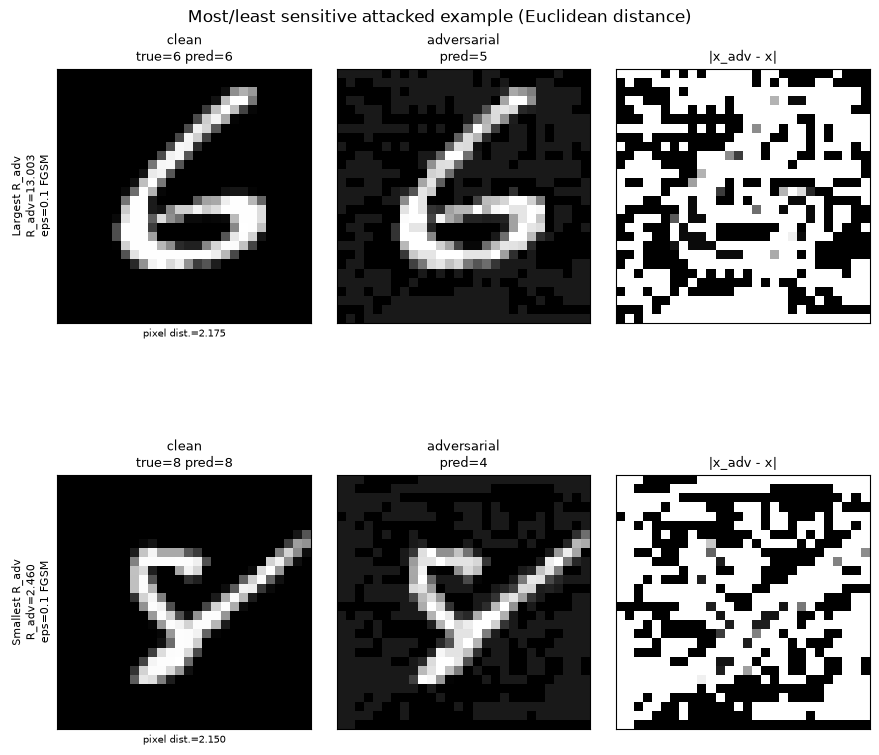

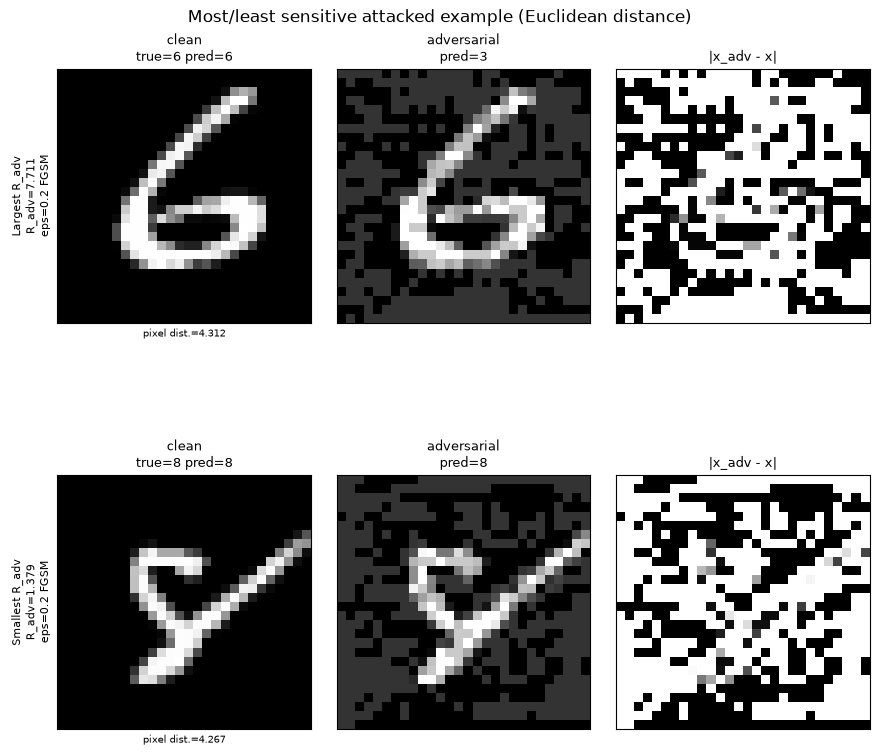

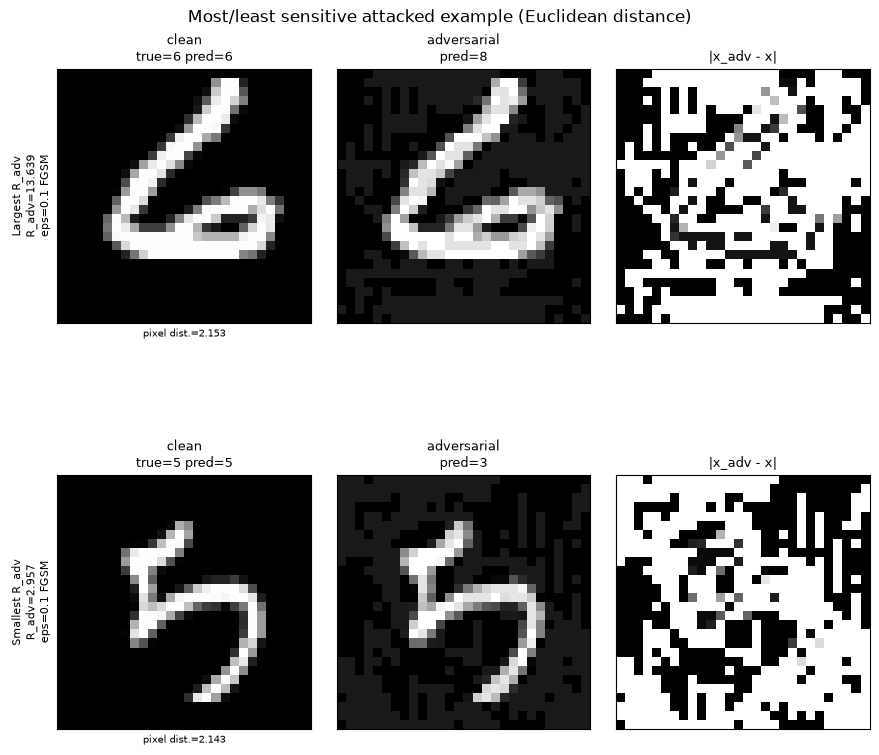

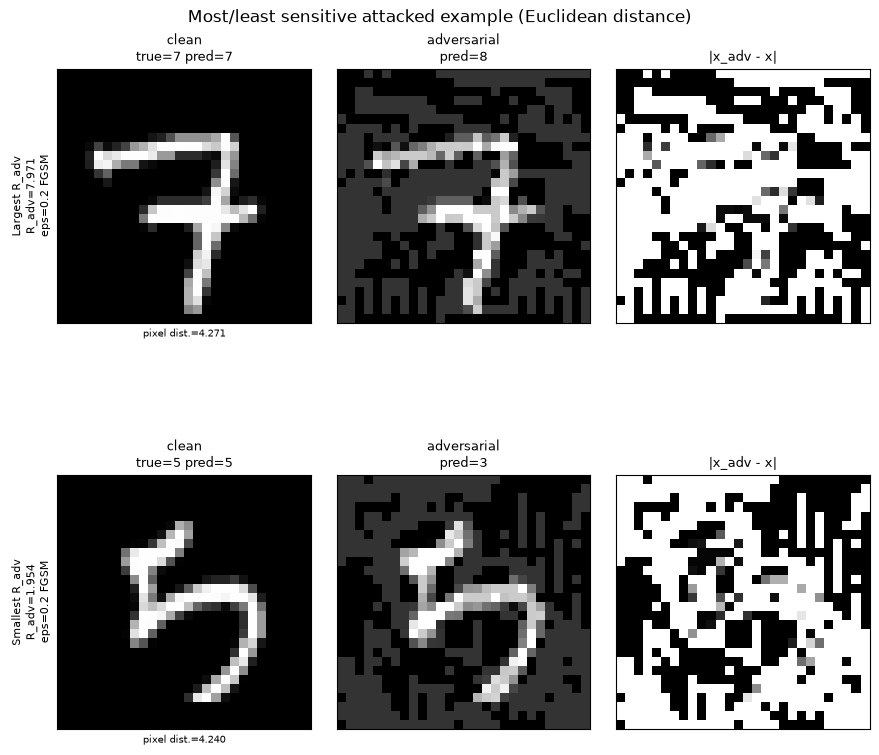

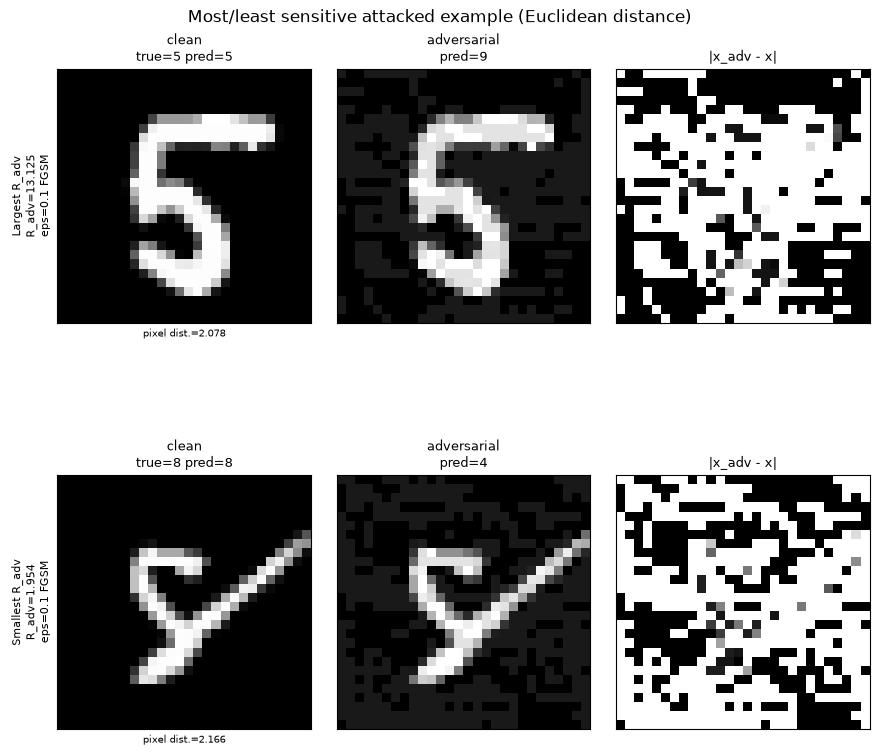

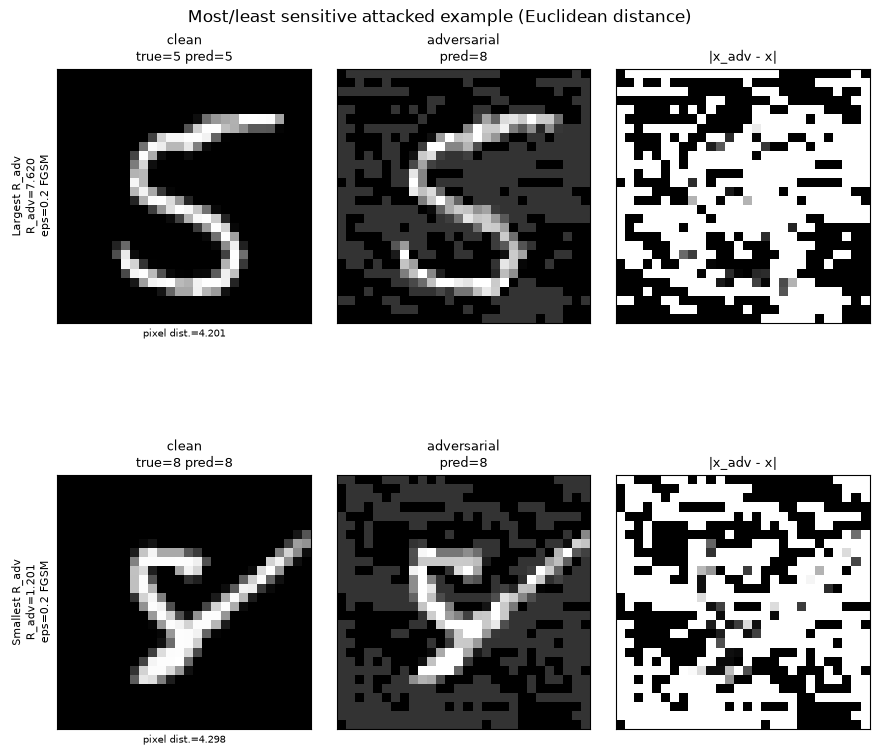

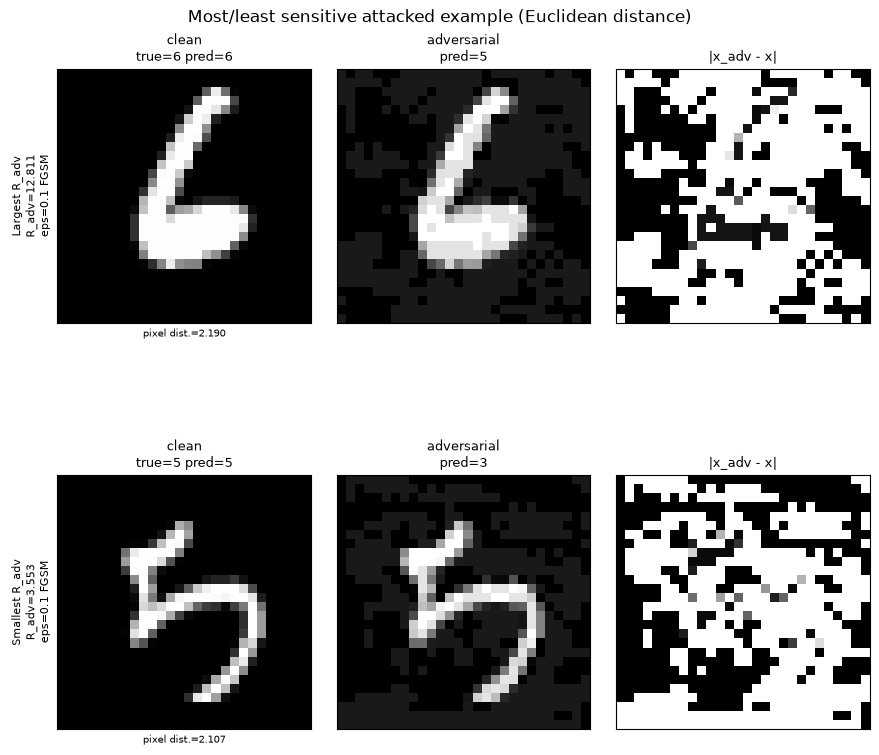

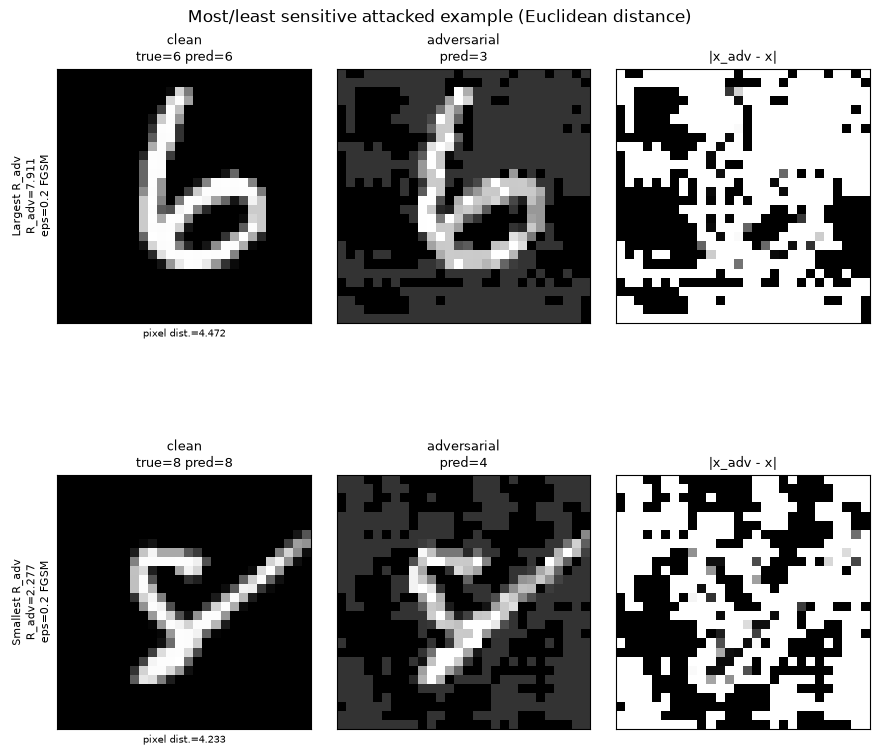

In [17]:
for seed in sweep.SEEDS:
    for epsilon in sweep.EPSILONS:
        most_sensitive = sweep.extract_extreme_example(
            models_by_seed[seed], test, pool, r_adv_df, seed=seed, epsilon=epsilon,
            which="most_sensitive")
        least_sensitive = sweep.extract_extreme_example(
            models_by_seed[seed], test, pool, r_adv_df, seed=seed, epsilon=epsilon,
            which="least_sensitive")
        adv_plots.plot_extreme_examples(
            most_sensitive, least_sensitive, metric_name="Euclidean",
            save_path=sweep.RESULTS_DIR / f"strong_cnn_seed_sweep_extreme_seed{seed}_eps{epsilon:g}.png")


## Step 7: transferability -- do seed=0's adversarial examples fool the OTHER seeds?

Every comparison above attacks each seed's OWN model and measures sensitivity on ITS OWN logits --
it never asks whether an adversarial example crafted for ONE model also fools a DIFFERENT,
independently-trained one. That's the classic adversarial-transferability question (Goodfellow et
al. 2015's ensemble-of-twelve-maxout-networks result is itself a transferability finding), and the
Findings section above only engaged with it indirectly, via the common-success-set overlap of five
INDEPENDENTLY-crafted attacks. This section asks it directly: fix seed=0's adversarial examples
(computed once per epsilon, attacking ONLY seed 0), then evaluate every seed's clean-vs-adversarial
accuracy and R_adv on those SAME fixed images -- `run_transfer_attack`'s `eval_seed == source_seed`
row is exactly the ordinary (non-transfer) attack already computed in Step 3; every other
`eval_seed` row is the new transfer measurement.


**Output columns** (`transfer_df`, one row per `(source_seed, eval_seed, epsilon, pool position)`):
- `source_seed` -- always `0` here: whose model the adversarial examples were crafted against.
- `eval_seed` -- whose model is being evaluated on those fixed images (0-4, including the source).
- `epsilon`, `pool_position`, `test_index` -- same meaning as in `r_adv_df` (Step 3).
- `is_misclassified` -- whether `eval_seed`'s OWN model misclassifies the (seed-0-crafted)
  adversarial image.
- `R_adv_euclidean`/`R_adv_mahalanobis` -- `eval_seed`'s own achieved sensitivity ratio on the
  fixed `(x, x_adv)` pair -- same formula as everywhere else in this notebook, just evaluated
  under a DIFFERENT model than the one that produced `x_adv`.


In [18]:
transfer_df = sweep.run_transfer_attack(
    models_by_seed, test, pool, mahalanobis_distance_fn, source_seed=0,
    epsilons=sweep.EPSILONS, verbose=True)
transfer_df.head()


  source_seed=0  eval_seed=0  epsilon=0.1  transfer_pct_misclassified=0.6568


  source_seed=0  eval_seed=1  epsilon=0.1  transfer_pct_misclassified=0.4222


  source_seed=0  eval_seed=2  epsilon=0.1  transfer_pct_misclassified=0.5028


  source_seed=0  eval_seed=3  epsilon=0.1  transfer_pct_misclassified=0.3864


  source_seed=0  eval_seed=4  epsilon=0.1  transfer_pct_misclassified=0.3157


...

  source_seed=0  eval_seed=1  epsilon=0.2  transfer_pct_misclassified=0.8036


  source_seed=0  eval_seed=2  epsilon=0.2  transfer_pct_misclassified=0.8465


  source_seed=0  eval_seed=3  epsilon=0.2  transfer_pct_misclassified=0.8258


  source_seed=0  eval_seed=4  epsilon=0.2  transfer_pct_misclassified=0.7326


,source_seed,eval_seed,epsilon,pool_position,test_index,is_misclassified,R_adv_euclidean,R_adv_mahalanobis
0,0,0,0.1,0,0,False,9.292597,1.374576
1,0,0,0.1,1,1,True,8.801993,1.261284
2,0,0,0.1,2,2,True,9.147294,1.473703
3,0,0,0.1,3,3,True,8.424584,1.217699
4,0,0,0.1,4,4,True,7.977288,1.106874


**Output columns** (`transfer_summary_df`, one row per `(source_seed, eval_seed, epsilon)`):
- `transfer_accuracy` -- `1 - mean(is_misclassified)`: the fraction of the pool `eval_seed`'s
  model STILL gets right despite the seed-0-crafted perturbation. At `eval_seed=0` this is exactly
  the ordinary adversarial accuracy from Step 3/5 (`adv_acc_eps...` in `project1_summary_df`); at
  every other `eval_seed`, a value close to `1.0` would mean seed 0's adversarial examples barely
  transfer, while a value close to seed 0's own `transfer_accuracy` would mean they transfer
  almost as well as attacking that model directly.
- `mean_R_adv_euclidean`/`p99_R_adv_euclidean` -- mean/99th-percentile achieved sensitivity, under
  Euclidean distance, evaluated on `eval_seed`'s own logits.
- `mean_R_adv_mahalanobis`/`p99_R_adv_mahalanobis` -- the same, under Mahalanobis distance.


In [19]:
transfer_summary_df = sweep.summarize_transfer_attack(transfer_df)
transfer_summary_df.sort_values(["epsilon", "eval_seed"])


,source_seed,eval_seed,epsilon,transfer_accuracy,mean_R_adv_euclidean,p99_R_adv_euclidean,mean_R_adv_mahalanobis,p99_R_adv_mahalanobis
0,0,0,0.1,0.343225,8.399805,12.063196,1.224860,1.787525
2,0,1,0.1,0.577809,7.480302,11.152007,1.093452,1.645548
4,0,2,0.1,0.497234,8.257020,11.752470,1.204557,1.727844
6,0,3,0.1,0.613620,7.489731,10.738855,1.093679,1.596772
8,0,4,0.1,0.684338,7.426353,10.285234,1.084724,1.534432
1,0,0,0.2,0.101298,4.992455,6.932671,0.727418,1.019584
3,0,1,0.2,0.196359,4.734810,6.683441,0.691189,0.986004
5,0,2,0.2,0.153506,5.010205,7.046612,0.730389,1.028488
7,0,3,0.2,0.174228,4.733321,6.593532,0.690299,0.976635
9,0,4,0.2,0.267378,4.755183,6.636618,0.692670,0.961443


Bar heights are `transfer_accuracy` (top row) and `p99(R_adv)` (bottom row) vs. `eval_seed`; the
`eval_seed=0` bar is outlined in black since it's the non-transfer (ordinary) attack, included for
direct comparison against the four genuinely transferred cases. If the bars are roughly flat
across `eval_seed`, seed 0's adversarial examples are about as effective against every other seed
as they are against seed 0 itself -- strong transferability, consistent with Goodfellow et al.
(2015). A markedly taller `transfer_accuracy` bar (or smaller `p99(R_adv)` bar) at the other seeds
would mean the attack is comparatively seed-0-specific and transfers only partially.


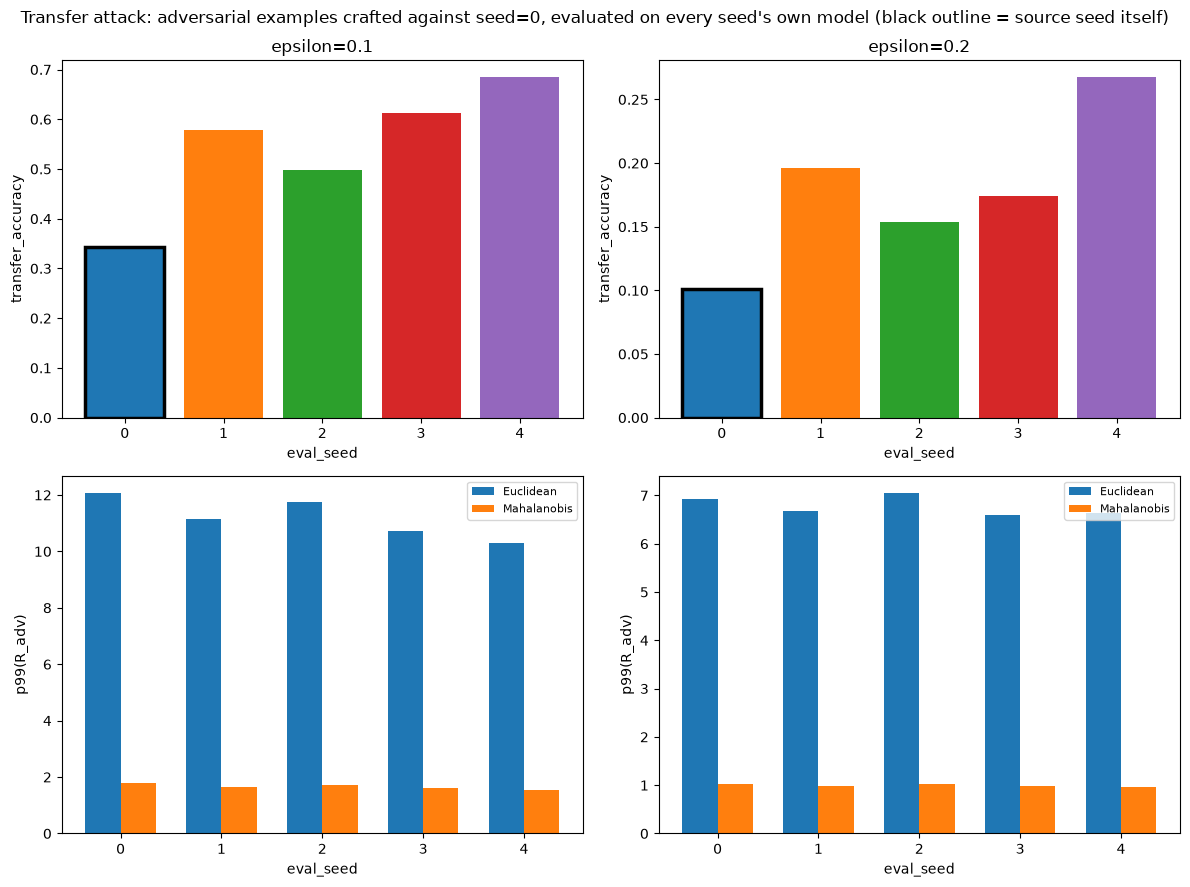

In [20]:
fig_transfer = adv_plots.plot_transfer_attack(
    transfer_summary_df, source_seed=0,
    save_path=sweep.RESULTS_DIR / "strong_cnn_seed_sweep_transfer_attack_source0.png")


## Findings and observations

All numbers below are from the actual run in `results/` (5 seeds, full 60k MNIST, 25 epochs each,
`n_points=9941` common pool, FGSM only, epsilons `{0.1, 0.2}`). Confirmed test gates: 5 distinct
checkpoints with distinct hashes; reload reproduces logged accuracy exactly for all 5 seeds;
accuracy-premise check passed (`test_acc` range `[99.64%, 99.67%]`, max deviation from mean
0.018pp against a 0.5pp threshold); common pool = 9941/10000 (99.41%), programmatically verified
correct under all 5 models; realized-vs-Mahalanobis x_adv sharing confirmed by construction and by
a numerator-consistency check; percentile computation hand-verified against `numpy.quantile`.

### 1. Goal A -- does the Mahalanobis flip reproduce, and is it shrinkage-robust?

**Yes, in 5/5 seeds, at both attack epsilons, and at both Mahalanobis shrinkage values tested.**
`ratio_to_L_full` (p99(R_adv) / L_full_estimated, mean across seeds, with per-seed range):

| epsilon | Euclidean | Mahalanobis (eps=0.01) | Mahalanobis (eps=0.1) |
|---|---|---|---|
| 0.1 | 2.63x (2.55-2.73) | 1.04x (0.97-1.10) | 1.65x (1.58-1.76) |
| 0.2 | 1.56x (1.53-1.58) | 0.61x (0.57-0.65) | 0.98x (0.93-1.01) |

At every epsilon tested, `Mahalanobis (eps=0.01) < Mahalanobis (eps=0.1) < Euclidean` -- the
gap-narrowing direction never flips across the shrinkage sweep, in any of the 5 seeds. The
*magnitude* of the effect is shrinkage-dependent (heavier regularization, eps=0.1, pulls the ratio
toward the Euclidean value, exactly as expected since `mahalanobis_distance` converges to scaled
Euclidean distance as epsilon grows -- see `distance.py`'s own documented property), but the
qualitative finding from the single-seed run -- Euclidean R_adv exceeds the tight Lipschitz bound
while Mahalanobis R_adv sits at or below it -- reproduces cleanly and is not an artifact of one
particular shrinkage choice.

### 2. Goal B -- seed-to-seed variation, given matched clean accuracy

Clean test accuracy is matched to within 0.03pp across seeds (99.64-99.67%) by construction. Given
that, cross-seed variation is **small in the continuous R_adv/Lipschitz-bound quantities but
noticeably larger in the binary attack-success-rate**:

| Quantity | Range across seeds | Relative spread |
|---|---|---|
| p99(R_adv), Euclidean, eps=0.2 | 6.896-7.131 | ~3.4% |
| p99(R_adv), Mahalanobis, eps=0.2 | 0.996-1.081 | ~8.3% |
| `L_full_estimated`, Euclidean | 4.387-4.509 | ~2.7% |
| `L_full_estimated`, Mahalanobis (eps=0.01) | 1.646-1.835 | ~11.2% |
| `looseness_ratio`, Euclidean | 1.438-1.493 | ~3.7% |
| `looseness_ratio`, Mahalanobis (eps=0.01) | 1.417-1.472 | ~3.9% |
| **adversarial accuracy, eps=0.1** | 33.6%-46.2% | **~31%** |
| **adversarial accuracy, eps=0.2** | 10.1%-14.7% | **~39%** |

The continuous, distribution-level quantities (visible directly in the cross-seed overlay figure
above, where all five seeds' R_adv histograms sit nearly on top of each other) are tightly
reproducible across seeds -- single-digit percent spreads throughout. The **outcome-level**
quantity (what fraction of attacks actually flip the prediction) varies far more in RELATIVE terms,
even though the absolute spread is small at eps=0.2 (4.6 percentage points). This is a real,
reportable asymmetry, not a contradiction: `by_outcome_split` shows misclassified points have a
systematically smaller clean margin than correctly-classified ones in every seed (e.g. seed 0,
eps=0.1: 11.65 vs. 14.47) -- so a small seed-to-seed shift in exactly which points sit near a
decision boundary can move the success-rate substantially while barely moving the overall
sensitivity distribution.

**Known limitation, stated explicitly per the plan**: no within-seed noise floor was computed here
(each seed was evaluated once, not resampled/bootstrapped against its own fixed weights), so this
run cannot formally separate "the model differs across seeds" from "measurement/attack-sampling
noise would produce a similar spread even for one fixed model." The common evaluation pool
controls for *which images* are compared, but not for this second source of variation. This is the
same gap `seed_sweep.py`'s own `run_attack_seed_variance_decomposition` was built to close for the
`SmallCNN` width sweep; no analogous decomposition was run here.

### 3. Relation to Goodfellow et al. (2015)

Goodfellow et al.'s ensemble-of-twelve-maxout-networks finding -- that independently seeded models
trained on the same task learn similar functions and are comparably vulnerable to the same
adversarial examples -- is **broadly supported at the level of the overall sensitivity
distribution** (point 2's tight R_adv/Lipschitz-bound agreement) but **complicated at the level of
individual outcomes**: which specific images flip at a given epsilon is more seed-sensitive
(~31-39% relative spread in adversarial accuracy) than how sensitive the network is on average.
The common-success-set check adds a second angle on the same question -- of the 9941-image pool,
4018 images (40.4%) are misclassified by **all five** seeds at eps=0.1, and 7722 (77.7%) at
eps=0.2, both comfortably above the plan's 50-image reliability floor. A large, robust core of
universally-fragile examples exists across independently-trained models -- consistent with
Goodfellow et al.'s claim that adversarial vulnerability is a shared property of the task/decision
boundary, not an idiosyncrasy of one training run -- while the remaining minority of points
(59.6% at eps=0.1) are flipped by only some seeds, which is where the larger relative variation in
adversarial accuracy comes from.

### 4. Looseness ratio stability (secondary finding)

Very stable across seeds under both metrics: Euclidean 1.438-1.493 (mean 1.471), Mahalanobis
(eps=0.01) 1.417-1.472 (mean 1.441) -- both within ~4% of their own mean. This roughly matches the
original single-checkpoint run's values (Euclidean 1.47x, Mahalanobis 1.36x from
`strong_cnn_experiment.py`'s README section) for Euclidean almost exactly, and is somewhat higher
than that single run's Mahalanobis value, though still in a comparable range and well within this
sweep's own seed-to-seed spread -- not a large discrepancy given the two runs differ in
`n_query_points` (500 vs. this sweep's 1000) and therefore sample a different random set of
query-point pairs for the pairwise Lipschitz estimate.

### 5. Realized vs. nominal perturbation norm

**No fix was needed, contrary to the plan's anticipation.** `achieved_ratio`'s denominator was
already `distance_fn(x, x_adv)` -- the actual, post-clipping distance -- before this sweep was
written, confirmed by reading the implementation directly (see `build_r_adv_table`'s docstring).
The realized/nominal ratio is consistently ~0.76-0.78 across every seed and epsilon (FGSM clips
substantially at these settings, since most MNIST background pixels are already saturated at 0),
confirmed stable and not epsilon-dependent in a way that would bias the epsilon=0.1-vs-0.2
comparison. Because the original single-checkpoint run used the same `achieved_ratio` function,
**this sweep's numbers ARE directly comparable to that run's** -- there is no realized-vs-nominal
incomparability caveat to apply here.

### 6. Determinism caveat

`torch.manual_seed` and data-loader seeding were set per training run; `torch.use_deterministic_algorithms(True)`
was NOT forced. Environment: CPU only (no CUDA available), `torch.__version__` and platform
recorded in the first code cell of this notebook. The five checkpoints therefore measure
*training-run* variation (initialization + data order + any residual CPU-arithmetic
nondeterminism), not *initialization-seed* variation in strict isolation -- consistent with this
being the quantity Goal B is actually asking about (how much do independently-trained runs of a
fixed architecture/recipe vary), not a narrower controlled-initialization-only experiment.

### 7. Transferability -- do seed=0's adversarial examples fool the OTHER seeds?

**Yes, substantially, but consistently less effectively than attacking seed 0 directly.**
`transfer_accuracy` (higher = attack LESS effective) at each `eval_seed`, source_seed=0:

| epsilon | seed=0 (self) | seed=1 | seed=2 | seed=3 | seed=4 |
|---|---|---|---|---|---|
| 0.1 | 34.3% | 57.8% | 49.7% | 61.4% | 68.4% |
| 0.2 | 10.1% | 19.6% | 15.4% | 17.4% | 26.7% |

At every epsilon, the self-attack (`eval_seed=0`) is the MOST effective by a clear margin -- the
attack degrades under transfer, consistent with the adversarial direction being at least somewhat
specific to seed 0's exact decision boundary, not a boundary shared identically by all five models.
But the degradation is partial, not total: at eps=0.1, misclassification drops from 65.7% (self)
to a 40.7% average across the other four seeds -- still a substantial fraction of the pool fooled
by an attack that never saw that seed's weights. At eps=0.2 the transfer is even stronger in
relative terms (89.9% self misclassification vs. 80.2% average transfer misclassification) --
consistent with a larger perturbation being less dependent on precisely which model's gradient
produced it.

**R_adv barely changes between self-attack and transfer-attack, even though the outcome does.**
`mean_R_adv_euclidean` at epsilon=0.2 ranges only 4.73-5.01 across ALL FIVE `eval_seed` values
(including seed 0 itself) -- a ~5.5% spread, similar in size to Goal B's own cross-seed spread for
the ordinary (non-transfer) attack. The same holds for `mean_R_adv_mahalanobis` (0.69-0.73). This
is a striking, concrete illustration of the asymmetry already noted in point 2 above: a fixed
perturbation moves every model's logits by a SIMILAR amount regardless of which model it was
crafted against (R_adv is stable), but whether that movement is enough to cross the
(seed-specific) decision boundary and actually flip the prediction is much more sensitive to which
model is doing the classifying (`transfer_accuracy` varies by up to 34 percentage points across
`eval_seed` at epsilon=0.1). The continuous sensitivity landscape is shared across independently
trained models; the exact location of the decision boundary within it is not.

This is a more direct, causal version of Goodfellow et al. (2015)'s transferability claim than the
common-success-set check in point 3: rather than comparing five INDEPENDENTLY-crafted attacks'
overlap, this fixes ONE attack and asks how well it generalizes -- and finds meaningful but
incomplete transfer, matching the qualitative expectation from that paper (adversarial examples
transfer across independently-trained models, but not perfectly).
